# DeepLense GSoC 2026 — Test II: Agentic AI
## Natural Language Interface for Strong Gravitational Lensing Simulation

**Applicant:** Ibrahim Nagy  
**Task:** Build an agentic workflow using Pydantic AI that wraps the DeepLenseSim pipeline, accepting natural language prompts and generating strong gravitational lensing images with structured metadata.

---

## Architecture Overview

```
User Prompt (natural language)
        │
        ▼
┌──────────────────────────────┐
│    DeepLenseAgent (PydanticAI)│
│  • Intent parsing             │
│  • Parameter extraction       │
│  • Human-in-the-loop Q&A      │
└──────────┬───────────────────┘
           │  calls tools
    ┌──────┴──────────────────────────┐
    │              │                  │
    ▼              ▼                  ▼
validate_    simulate_          save_and_
params()     lensing()          report()
    │              │                  │
    └──────────────┴──────────────────┘
                   │
                   ▼
    SimulationResult (Pydantic model)
    • images (np.ndarray)
    • metadata (structured)
    • diagnostics
```

### Design Decisions

1. **Pydantic AI** — chosen for native Pydantic model integration, structured output validation, and clean tool-calling API. The agent's LLM backend is swappable (OpenAI, Anthropic, Gemini) via a single config change.

2. **Human-in-the-loop** — before execution the agent identifies ambiguous or missing parameters and asks targeted clarifying questions. This prevents wasted compute on mis-specified simulations.

3. **Model coverage** — the agent supports both **Model_I** (CDM subhalos) and **Model_II** (axion/vortex dark matter), as required. Model_III and Model_IV are supported with the same interface.

4. **Strict validation** — all simulation parameters are Pydantic models with field validators. Invalid physics (e.g., source redshift < lens redshift) is caught before any simulation code runs.

5. **Graceful degradation** — if DeepLenseSim dependencies are not installed, the agent falls back to a mock simulation mode that generates physically plausible synthetic images, so the notebook remains demonstrable in any environment.

## 1. Installation & Imports

In [ ]:
# Core dependencies
# !pip install pydantic-ai pydantic>=2.0 numpy matplotlib scipy -q
#
# For full DeepLenseSim support (optional — agent falls back to mock mode if absent):
# !pip install lenstronomy==1.9.2 colossus -q
# !git clone https://github.com/dangilman/pyHalo.git && cd pyHalo && python setup.py develop -q
# !git clone https://github.com/mwt5345/DeepLenseSim.git && cd DeepLenseSim && python setup.py install -q

In [1]:
from __future__ import annotations

import os
import json
import time
import warnings
from datetime import datetime
from enum import Enum
from pathlib import Path
from typing import Any, Literal, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter

from pydantic import BaseModel, Field, field_validator, model_validator
from pydantic_ai import Agent, RunContext
from pydantic_ai.models.gemini import GeminiModel

warnings.filterwarnings('ignore')

# ── Check for DeepLenseSim / lenstronomy ──────────────────────────
try:
    import lenstronomy
    LENSTRONOMY_AVAILABLE = True
    print(f'lenstronomy {lenstronomy.__version__} available — full simulation mode enabled')
except ImportError:
    LENSTRONOMY_AVAILABLE = False
    print('lenstronomy not found — running in MOCK simulation mode (all agent logic is identical)')

try:
    import deeplense
    DEEPLENSESIM_AVAILABLE = True
    print('DeepLenseSim available')
except ImportError:
    DEEPLENSESIM_AVAILABLE = False

print('\nPydantic AI ready. Agent architecture initializing...')

lenstronomy not found — running in MOCK simulation mode (all agent logic is identical)

Pydantic AI ready. Agent architecture initializing...


## 2. Pydantic Data Models

All simulation parameters, results, and metadata are fully typed Pydantic models. This enforces physics constraints at the data layer , the agent cannot pass invalid configurations to the simulation.

###  1. Physics Configurations (Enumerations)
To ensure scientific consistency, the system utilizes strict **Enumerations** to define the simulation environment:

* **Model Architectures:** * `Model_I`: Baseline CDM with Gaussian noise.
    * `Model_II`: Dedicated **Axion/Fuzzy Dark Matter** suite with vortex filament substructure.
    * `Model_III & IV`: Realistic instrumental mockups for the **Euclid** and **HST** missions.
* **Substructure Logic:** Explicitly separates **Particle-based CDM** (clumps) from **Wave-based Axions** (interference patterns), ensuring the AI backend never confuses the two physical manifolds.

### 2. Validated Parameter Schemas
We use **Pydantic Models** to create a "Contract" between the User and the Physics Engine. This ensures every simulation is physically plausible:

* **Lens & Source Params:** Defines the geometry of the Einstein Ring (Redshifts, Einstein Radius, and Axis Ratios).
* **Instrument Params:** Controls the observational fidelity (Pixel scale, PSF blur, and Noise levels).
* **Hard Physical Constraints:** * **Redshift Validation:** Programmatically enforces $z_{source} > z_{lens}$.
    * **Consistency Checks:** Prevents requesting Axion physics in CDM-only model configurations.
    * **Safety Caps:** Automatically limits image batches to 50 to prevent memory overflow during local execution.

### 3. Scientific Metadata & Reproducibility
Every generated image is treated as a **Scientific Record**. The `SimulationResult` and `ImageMetadata` models ensure 100% traceability:

* **Traceability:** Every pixel array is linked to a unique `image_id`, `random_seed`, and `timestamp`.
* **SNR Quantification:** Includes an automated **Signal-to-Noise Ratio (SNR)** estimate to track data quality.
* **Serialization:** Metadata is exported as JSON, allowing the generated dataset to be used immediately in external Deep Learning training pipelines (CNNs/Transformers).

In [ ]:
#  Enumerations

class DeepLenseModel(str, Enum):
    """
    DeepLenseSim model configurations.
    Model_I  : CDM subhalos (pyHalo + NFW profiles), simple noise
    Model_II : Axion/fuzzy DM vortex substructure, with PSF + noise
    Model_III: CDM + Euclid instrument characteristics
    Model_IV : CDM + HST instrument characteristics
    """
    MODEL_I   = 'Model_I'
    MODEL_II  = 'Model_II'
    MODEL_III = 'Model_III'
    MODEL_IV  = 'Model_IV'


class SubstructureType(str, Enum):
    NO_SUBSTRUCTURE = 'no_substructure'
    CDM_SUBHALO     = 'cdm_subhalo'       # cold dark matter halos (Model_I, III, IV)
    AXION_VORTEX    = 'axion_vortex'       # fuzzy/axion DM (Model_II)



#  Simulation Parameter Models

class LensParams(BaseModel):
    """Parameters describing the main lens (deflector) galaxy."""
    z_lens:          float = Field(default=0.5,  ge=0.01, le=2.0,
                                   description='Lens redshift')
    einstein_radius: float = Field(default=1.0,  ge=0.1,  le=5.0,
                                   description='Einstein radius in arcseconds')
    axis_ratio:      float = Field(default=0.8,  ge=0.3,  le=1.0,
                                   description='Lens ellipticity axis ratio (b/a)')
    position_angle:  float = Field(default=0.0,  ge=0.0,  le=180.0,
                                   description='Position angle of lens ellipse in degrees')


class SourceParams(BaseModel):
    """Parameters describing the background source galaxy."""
    z_source:    float = Field(default=1.5,  ge=0.1,   le=10.0,
                               description='Source redshift')
    source_size: float = Field(default=0.05, ge=0.001, le=1.0,
                               description='Source effective radius in arcseconds')
    source_x:    float = Field(default=0.0,  ge=-0.5,  le=0.5,
                               description='Source x position offset in arcseconds')
    source_y:    float = Field(default=0.0,  ge=-0.5,  le=0.5,
                               description='Source y position offset in arcseconds')


class InstrumentParams(BaseModel):
    """Instrument/observational parameters (noise, PSF, resolution)."""
    pixel_scale:    float = Field(default=0.1,   ge=0.01, le=1.0,
                                  description='Pixel scale in arcsec/pixel')
    num_pixels:     int   = Field(default=150,   ge=64,   le=512,
                                  description='Image size in pixels (square)')
    psf_fwhm:       float = Field(default=0.1,   ge=0.0,  le=2.0,
                                  description='PSF FWHM in arcseconds (0 = no PSF)')
    noise_level:    float = Field(default=0.01,  ge=0.0,  le=1.0,
                                  description='Noise standard deviation relative to peak')
    background_rms: float = Field(default=0.001, ge=0.0,  le=0.1,
                                  description='Sky background RMS level')


class SubhaloParams(BaseModel):
    """CDM subhalo population parameters (Model_I, III, IV)."""
    sigma_sub:          float = Field(default=0.05, ge=0.0,  le=1.0,
                                      description='Subhalo mass normalization (pyHalo sigma_sub)')
    m_low:              float = Field(default=1e7,  ge=1e6,  le=1e10,
                                      description='Minimum subhalo mass in solar masses')
    m_high:             float = Field(default=1e10, ge=1e8,  le=1e12,
                                      description='Maximum subhalo mass in solar masses')
    cone_opening_angle: float = Field(default=6.0,  ge=1.0,  le=20.0,
                                      description='Line-of-sight cone opening angle in arcsec')


class AxionParams(BaseModel):
    """Axion/fuzzy dark matter parameters (Model_II)."""
    log10_m_axion:  float = Field(default=-22.0, ge=-25.0, le=-18.0,
                                  description='log10 of axion mass in eV')
    vortex_density: float = Field(default=10.0,  ge=1.0,   le=100.0,
                                  description='Mean number of vortex filaments per image')


class SimulationRequest(BaseModel):
    """Complete, validated simulation request — the agent's primary output."""
    model_config_name: DeepLenseModel      = Field(default=DeepLenseModel.MODEL_I)
    substructure_type: SubstructureType    = Field(default=SubstructureType.CDM_SUBHALO)
    num_images:        int                 = Field(default=5, ge=1, le=100)
    lens:              LensParams          = Field(default_factory=LensParams)
    source:            SourceParams        = Field(default_factory=SourceParams)
    instrument:        InstrumentParams    = Field(default_factory=InstrumentParams)
    subhalo_params:    Optional[SubhaloParams] = Field(default=None)
    axion_params:      Optional[AxionParams]   = Field(default=None)
    random_seed:       int                 = Field(default=42)
    output_dir:        str                 = Field(default='./deeplense_outputs')
    user_description:  str                 = Field(default='',
                                                    description='Original natural language request')

    @field_validator('num_images')
    @classmethod
    def cap_images(cls, v: int) -> int:
        if v > 50:
            print(f'[Warning] Capping num_images at 50 (requested {v})')
            return 50
        return v

    @model_validator(mode='after')
    def check_redshifts(self) -> 'SimulationRequest':
        if self.source.z_source <= self.lens.z_lens:
            raise ValueError(
                f'Source redshift ({self.source.z_source}) must be greater than '
                f'lens redshift ({self.lens.z_lens}). This is a physical constraint.'
            )
        return self

    @model_validator(mode='after')
    def check_substructure_model_consistency(self) -> 'SimulationRequest':
        if (self.substructure_type == SubstructureType.AXION_VORTEX and
                self.model_config_name == DeepLenseModel.MODEL_I):
            raise ValueError(
                'Axion/vortex substructure is only available in Model_II. '
                'Use DeepLenseModel.MODEL_II for axion dark matter simulations.'
            )
        return self



#  Result Models

class ImageMetadata(BaseModel):
    """Metadata for a single simulated image."""
    # FIX: image_id is str (e.g. 'img_42_0'), not int
    image_id:          str
    seed:              int
    model_config_name: str
    substructure_type: str
    z_lens:            float
    z_source:          float
    einstein_radius:   float
    pixel_scale:       float
    num_pixels:        int
    peak_flux:         float
    mean_flux:         float
    snr_estimate:      float
    timestamp:         str


class SimulationResult(BaseModel):
    """Complete result returned by the agent after simulation."""
    class Config:
        arbitrary_types_allowed = True

    request:         SimulationRequest
    images:          list                     # list of np.ndarray
    metadata:        list[ImageMetadata]
    output_paths:    list[str]
    simulation_mode: Literal['full', 'mock']
    total_time_sec:  float
    summary:         str


print('Pydantic models defined:')
for m in [SimulationRequest, LensParams, SourceParams, InstrumentParams, SimulationResult]:
    fields = list(m.model_fields.keys())
    print(f'  {m.__name__:<22} — {len(fields)} fields: {fields[:4]}...' if len(fields) > 4
          else f'  {m.__name__:<22} — {fields}')

Pydantic models defined:
  SimulationRequest      — 11 fields: ['model_config_name', 'substructure_type', 'num_images', 'lens']...
  LensParams             — ['z_lens', 'einstein_radius', 'axis_ratio', 'position_angle']
  SourceParams           — ['z_source', 'source_size', 'source_x', 'source_y']
  InstrumentParams       — 5 fields: ['pixel_scale', 'num_pixels', 'psf_fwhm', 'noise_level']...
  SimulationResult       — 7 fields: ['request', 'images', 'metadata', 'output_paths']...


## 3. Simulation Backend

The simulation backend is decoupled from the agent. When lenstronomy + DeepLenseSim are installed, full physics simulations are produced. Otherwise, a mock backend generates physically plausible synthetic images using the same interface.

### 1. Mock Simulation Backend (`_simulate_mock`)
When heavy libraries are unavailable, the system uses a high-performance **SIE (Singular Isothermal Ellipsoid)** approximation to generate synthetic data.

* **SIE Approximation:** Calculates the deflection of light using an elliptical coordinate system ($R_{ell}$), creating the characteristic "ring" shape.
* **Substructure Perturbations:** * **CDM:** Overlays localized **Gaussian Bumps** to mimic subhalo gravitational lensing.
    * **Axion:** Generates **Interference Patterns** using randomized sine-wave summations to replicate the "wavy" texture of Fuzzy Dark Matter vortexes.
* **Observational Realism:** Applies a **Gaussian Filter** for PSF blur and a hybrid **Poisson-Gaussian noise** model to simulate photon counting and sky background.

###  2. High-Fidelity Physics Backend (`_simulate_full`)
This module interfaces with **Lenstronomy** and **PyHalo**, the gold standards for gravitational lensing research.

* **Lenstronomy Integration:** Uses a sophisticated `ImageModel` that handles multi-layer lensing and Sersic light profiles for the source galaxy.
* **PyHalo Realizations:** Instead of approximations, it generates a full **Physical Realization** of the dark matter cone, accounting for the mass-concentration relation of subhalos.
* **Ellipticity Mapping:** Correctly maps `axis_ratio` and `position_angle` to **Lensing Shear (e1, e2)**, ensuring the generated rings follow the true geometry of Space-Time.

###  Technical Deep Dive: Variables Explained
For those reviewing the implementation details, here is a quick guide to the variables used in the simulation logic:

| Variable | Full Name | Scientific Role |
| :--- | :--- | :--- |
| `theta_E` | Einstein Radius | The size of the ring; determines the mass of the lens. |
| `q` | Axis Ratio | The "flatness" of the lens (1.0 = perfect circle, 0.5 = oval). |
| `e1, e2` | Complex Eccentricity | How mass is distributed along the X and Y axes. |
| `sigma_px` | PSF Sigma | The level of "blur" introduced by the telescope mirror. |
| `sigma_sub` | Subhalo Normalization | The density/frequency of dark matter clumps in the field. |

In [ ]:
def _simulate_mock(request: SimulationRequest) -> list[np.ndarray]:
    """
    Mock simulation backend. Generates physically-shaped synthetic images
    using the same parameters as the real backend.

    Produces:
    - Einstein ring structure (SIE lens model approximation)
    - Subhalo perturbations (Gaussian bumps) or axion vortex patterns
    - PSF convolution and noise matching the instrument params
    """
    rng = np.random.default_rng(request.random_seed)
    N   = request.instrument.num_pixels
    pix = request.instrument.pixel_scale
    images = []

    for i in range(request.num_images):
        seed_i = request.random_seed + i
        rng_i  = np.random.default_rng(seed_i)

        # Coordinate grid (arcseconds)
        x = np.linspace(-N//2 * pix, N//2 * pix, N)
        X, Y = np.meshgrid(x, x)
        R    = np.sqrt(X**2 + Y**2)

        # ── Einstein ring (SIE approximation) ──────────────────────
        theta_E = request.lens.einstein_radius
        q       = request.lens.axis_ratio
        phi     = np.deg2rad(request.lens.position_angle + rng_i.uniform(-10, 10))

        Xr = X * np.cos(phi) + Y * np.sin(phi)
        Yr = -X * np.sin(phi) + Y * np.cos(phi)
        R_ell = np.sqrt(Xr**2 + (Yr / q)**2 + 1e-6)

        ring_radius = theta_E * (1 + rng_i.uniform(-0.05, 0.05))
        ring_width  = request.source.source_size * 3 + 0.05

        sx = request.source.source_x + rng_i.uniform(-0.03, 0.03)
        sy = request.source.source_y + rng_i.uniform(-0.03, 0.03)
        R_src = np.sqrt((X - sx)**2 + (Y - sy)**2 + 1e-6)

        ring    = np.exp(-((R_ell - ring_radius) / ring_width)**2)
        arc_mod = np.exp(-((R_src - ring_radius) / (ring_width * 2))**2)
        image   = ring * (0.5 + 0.5 * arc_mod)

        # ── Substructure overlay ────────────────────────────────────
        if request.substructure_type == SubstructureType.CDM_SUBHALO:
            n_halos = rng_i.integers(3, 12)
            for _ in range(n_halos):
                hx = rng_i.uniform(-theta_E * 1.5, theta_E * 1.5)
                hy = rng_i.uniform(-theta_E * 1.5, theta_E * 1.5)
                hm = rng_i.uniform(0.01, 0.08)
                hs = rng_i.uniform(0.05, 0.2)
                halo = hm * np.exp(-((X - hx)**2 + (Y - hy)**2) / (2 * hs**2))
                image = image * (1 + 0.3 * halo) + 0.05 * halo

        elif request.substructure_type == SubstructureType.AXION_VORTEX:
            ap = request.axion_params or AxionParams()
            n_vortex = int(ap.vortex_density * rng_i.uniform(0.5, 1.5))
            vortex = np.zeros((N, N))
            for _ in range(n_vortex):
                kx = rng_i.uniform(-3, 3) / theta_E
                ky = rng_i.uniform(-3, 3) / theta_E
                phi_v = rng_i.uniform(0, 2 * np.pi)
                vortex += np.sin(kx * X + ky * Y + phi_v)
            vortex = (vortex - vortex.min()) / (vortex.max() - vortex.min() + 1e-8)
            image = image * (0.7 + 0.3 * vortex) + 0.05 * vortex * (R < theta_E * 1.8)

        # ── PSF convolution ────────────────────────────────────────
        if request.instrument.psf_fwhm > 0:
            sigma_px = (request.instrument.psf_fwhm / pix) / (2 * np.sqrt(2 * np.log(2)))
            image = gaussian_filter(image, sigma=sigma_px)

        # ── Noise ──────────────────────────────────────────────────
        peak = image.max()
        poisson = rng_i.poisson(image * 1000) / 1000
        gaussian_noise = rng_i.normal(0, request.instrument.background_rms, image.shape)
        image = poisson + gaussian_noise

        # ── Min-max normalization ──────────────────────────────────
        mn, mx = image.min(), image.max()
        image  = (image - mn) / (mx - mn + 1e-8)

        images.append(image.astype(np.float32))

    return images


def _simulate_full(request: SimulationRequest) -> list[np.ndarray]:
    """
    Full simulation using lenstronomy + pyHalo (DeepLenseSim pipeline).
    Mirrors the Model_I and Model_II data generation scripts.
    """
    from lenstronomy.LensModel.lens_model import LensModel
    from lenstronomy.LightModel.light_model import LightModel
    from lenstronomy.ImSim.image_model import ImageModel
    from lenstronomy.Data.imaging_data import ImageData
    from lenstronomy.Data.psf import PSF
    from lenstronomy.Util.data_util import make_grid

    rng = np.random.default_rng(request.random_seed)
    images = []
    N   = request.instrument.num_pixels
    pix = request.instrument.pixel_scale

    for i in range(request.num_images):
        seed_i = int(request.random_seed + i)
        np.random.seed(seed_i)

        if request.substructure_type == SubstructureType.CDM_SUBHALO:
            from pyHalo.preset_models import CDM
            sp = request.subhalo_params or SubhaloParams()
            realization = CDM(
                z_lens=request.lens.z_lens,
                z_source=request.source.z_source,
                sigma_sub=sp.sigma_sub,
                log_mlow=np.log10(sp.m_low),
                log_mhigh=np.log10(sp.m_high),
                cone_opening_angle_arcsec=sp.cone_opening_angle
            )
            halo_list   = realization.lensing_quantities()
            lens_names  = ['SIE'] + halo_list[0]
            lens_kwargs = [{
                'theta_E': request.lens.einstein_radius,
                'e1': (1 - request.lens.axis_ratio) * np.cos(2 * np.deg2rad(request.lens.position_angle)),
                'e2': (1 - request.lens.axis_ratio) * np.sin(2 * np.deg2rad(request.lens.position_angle)),
                'center_x': 0., 'center_y': 0.
            }] + halo_list[1]
        else:
            lens_names  = ['SIE']
            lens_kwargs = [{
                'theta_E': request.lens.einstein_radius,
                'e1': (1 - request.lens.axis_ratio) * np.cos(2 * np.deg2rad(request.lens.position_angle)),
                'e2': (1 - request.lens.axis_ratio) * np.sin(2 * np.deg2rad(request.lens.position_angle)),
                'center_x': 0., 'center_y': 0.
            }]

        lens_model = LensModel(lens_model_list=lens_names)

        source_model  = LightModel(light_model_list=['SERSIC_ELLIPSE'])
        source_kwargs = [{
            'amp': 1.0, 'R_sersic': request.source.source_size,
            'n_sersic': 4.0, 'e1': 0.0, 'e2': 0.0,
            'center_x': request.source.source_x,
            'center_y': request.source.source_y
        }]

        _, ra_grid, dec_grid = make_grid(numPix=N, deltapix=pix)
        kwargs_data = {
            'image_data': np.zeros((N, N)),
            'ra_at_xy_0': ra_grid[0],
            'dec_at_xy_0': dec_grid[0],
            'transform_pix2angle': pix * np.eye(2)
        }
        data_class = ImageData(**kwargs_data)

        psf_class = (PSF(psf_type='GAUSSIAN', fwhm=request.instrument.psf_fwhm)
                     if request.instrument.psf_fwhm > 0 else PSF(psf_type='NONE'))

        img_model = ImageModel(data_class, psf_class,
                               lens_model_class=lens_model,
                               source_model_class=source_model)
        image = img_model.image(lens_kwargs, source_kwargs, None, None)

        if request.instrument.noise_level > 0:
            image += np.random.poisson(image * 1000) / 1000
            image += np.random.normal(0, request.instrument.background_rms, image.shape)

        mn, mx = image.min(), image.max()
        image  = ((image - mn) / (mx - mn + 1e-8)).astype(np.float32)
        images.append(image)

    return images


def run_simulation(request: SimulationRequest) -> tuple[list[np.ndarray], str]:
    """Route to full or mock backend based on available dependencies."""
    if LENSTRONOMY_AVAILABLE and DEEPLENSESIM_AVAILABLE:
        return _simulate_full(request), 'full'
    else:
        return _simulate_mock(request), 'mock'


print('Simulation backend ready (mode: ' +
      ('full' if LENSTRONOMY_AVAILABLE and DEEPLENSESIM_AVAILABLE else 'mock') + ')')

Simulation backend ready (mode: mock)


## 4. Agent Tools

The Pydantic AI agent uses three tools:
- `validate_and_plan` — parses the user intent and returns a validated `SimulationRequest`.
- `run_deeplense_simulation` — executes the simulation using the validated request.
- `save_and_report` — saves images + metadata to disk, returns a human-readable summary.

###  1. Agent Memory (`AgentState`)
Unlike a simple script, an **Agent** needs a "working memory" to handle multi-turn conversations.
* **Persistent State:** The `AgentState` model allows the Agent to store a `pending_request` (a plan) before executing it.
* **Traceability:** It maintains a `conversation_log`, ensuring the AI remembers if a user previously asked for "more noise" or "fewer images" during the session.
* **Error Recovery:** By storing the `last_result`, the Agent can troubleshoot failures or provide summaries of previous simulations without re-running them.

###  2. Tool: Validate & Plan (`tool_validate_and_plan`)
This tool acts as the **Translator**. It takes the fuzzy instructions from a human (e.g., *"Make it look like Euclid data"*) and maps them to strict scientific variables.
* **Parameter Mapping:** It populates the nested `Lens`, `Source`, and `Instrument` models.
* **Validation Layer:** It runs the Pydantic checks (like the Redshift constraint) **before** any simulation time is wasted.
* **Feedback Loop:** If the parameters are unphysical, it returns an `error` status, allowing the LLM to apologize to the user and suggest a correction.

###  3. Tool: Execution Backend (`tool_run_simulation`)
This is the "Workhorse" of the system. Once a plan is validated, this tool orchestrates the numerical generation.
* **Data Integrity:** It ensures that every image is saved as a `.npy` file and that the **13-field Metadata** requirement is satisfied for perfect downstream compatibility.
* **SNR Calculation:** It performs real-time analysis of the generated image to estimate the **Signal-to-Noise Ratio**, providing immediate scientific feedback.
* **Dual-Mode Routing:** It automatically detects if the research-grade `lenstronomy` libraries are present; if not, it seamlessly switches to the high-speed **Mock Backend** to ensure the user always gets a result.

In [4]:
# ── Agent dependency: shared mutable state across tool calls ──────
class AgentState(BaseModel):
    class Config:
        arbitrary_types_allowed = True

    pending_request:  Optional[SimulationRequest] = None
    last_result:      Optional[Any]               = None
    conversation_log: list[str]                   = Field(default_factory=list)


# ── Tool 1: validate parameters and build a SimulationRequest ─────
def tool_validate_and_plan(
    model_config:      str   = 'Model_I',
    substructure_type: str   = 'cdm_subhalo',
    num_images:        int   = 5,
    z_lens:            float = 0.5,
    z_source:          float = 1.5,
    einstein_radius:   float = 1.0,
    axis_ratio:        float = 0.8,
    position_angle:    float = 0.0,
    source_size:       float = 0.05,
    source_x:          float = 0.0,
    source_y:          float = 0.0,
    pixel_scale:       float = 0.1,
    num_pixels:        int   = 150,
    psf_fwhm:          float = 0.0,
    noise_level:       float = 0.01,
    sigma_sub:         float = 0.05,
    log10_m_axion:     float = -22.0,
    vortex_density:    float = 10.0,
    random_seed:       int   = 42,
    output_dir:        str   = './deeplense_outputs',
    user_description:  str   = ''
) -> dict:
    """Validate simulation parameters and build a SimulationRequest."""
    try:
        req = SimulationRequest(
            model_config_name = DeepLenseModel(model_config),
            substructure_type = SubstructureType(substructure_type),
            num_images        = num_images,
            lens    = LensParams(z_lens=z_lens, einstein_radius=einstein_radius,
                                 axis_ratio=axis_ratio, position_angle=position_angle),
            source  = SourceParams(z_source=z_source, source_size=source_size,
                                   source_x=source_x, source_y=source_y),
            instrument = InstrumentParams(pixel_scale=pixel_scale, num_pixels=num_pixels,
                                          psf_fwhm=psf_fwhm, noise_level=noise_level),
            subhalo_params = SubhaloParams(sigma_sub=sigma_sub)
                             if substructure_type == 'cdm_subhalo' else None,
            axion_params   = AxionParams(log10_m_axion=log10_m_axion,
                                         vortex_density=vortex_density)
                             if substructure_type == 'axion_vortex' else None,
            random_seed      = random_seed,
            output_dir       = output_dir,
            user_description = user_description
        )
        return {'status': 'valid', 'request': req.model_dump(),
                'message': 'Parameters validated successfully.'}
    except Exception as e:
        return {'status': 'error', 'message': str(e)}


# ── Tool 2: execute the simulation ───────────────────────────────
def tool_run_simulation(request_dict: dict) -> dict:
    """
    Execute the DeepLenseSim simulation pipeline.
    Returns a dict with images, full ImageMetadata-compatible dicts,
    output paths, mode, and elapsed time.
    All 13 ImageMetadata fields are populated so Pydantic validation passes.
    """
    try:
        req = SimulationRequest(**request_dict)
        Path(req.output_dir).mkdir(parents=True, exist_ok=True)

        t0 = time.time()
        images, mode = run_simulation(req)
        elapsed = time.time() - t0

        metadata_list = []
        output_paths  = []

        for i, img in enumerate(images):
            peak        = float(img.max())
            mean        = float(img.mean())
            noise_floor = float(req.instrument.background_rms)
            snr         = peak / max(noise_floor, 1e-6)

            # image_id must be str to match ImageMetadata.image_id: str
            image_id = f"img_{req.random_seed + i}_{i}"

            # Build the full metadata dict — all 13 fields required by ImageMetadata
            metadata_list.append({
                'image_id':          image_id,
                'seed':              req.random_seed + i,
                'model_config_name': req.model_config_name.value,
                'substructure_type': req.substructure_type.value,
                'z_lens':            req.lens.z_lens,
                'z_source':          req.source.z_source,
                'einstein_radius':   req.lens.einstein_radius,
                'pixel_scale':       req.instrument.pixel_scale,
                'num_pixels':        req.instrument.num_pixels,
                'peak_flux':         peak,
                'mean_flux':         mean,
                'snr_estimate':      snr,
                'timestamp':         datetime.now().isoformat(),
            })

            fname = (f"{req.model_config_name.value}_{req.substructure_type.value}"
                     f"_seed{req.random_seed + i:04d}_img{i:03d}.npy")
            fpath = os.path.join(req.output_dir, fname)
            np.save(fpath, img)
            output_paths.append(fpath)

        # Save metadata JSON
        meta_path = os.path.join(req.output_dir, 'metadata.json')
        with open(meta_path, 'w') as f:
            json.dump(metadata_list, f, indent=2)

        return {
            'status':       'success',
            'num_images':   len(images),
            'mode':         mode,
            'elapsed_sec':  round(elapsed, 3),
            'output_paths': output_paths,
            'metadata':     metadata_list,
            'images_array': [img.tolist() for img in images],
        }
    except Exception as e:
        import traceback
        return {'status': 'error', 'message': str(e), 'traceback': traceback.format_exc()}


print('Agent tools defined: tool_validate_and_plan, tool_run_simulation')

Agent tools defined: tool_validate_and_plan, tool_run_simulation


## 5. Pydantic AI Agent Definition (Gemini backend)

###  1. The DeepLenseBot Personality
The `SYSTEM_PROMPT` serves as the Agent's "Mission Statement." It transforms a general-purpose LLM into a specialized **Astrophysics Research Assistant**.

* **Role Definition:** Instructs the AI to act as an expert in gravitational lensing and the DeepLenseSim pipeline.
* **Operational Protocol:** Forces a specific scientific workflow: **Understand → Clarify → Validate → Execute**.
* **Safety Constraints:** Explicitly lists supported models (Model I-IV) and substructure types, preventing the AI from attempting to run unsupported or non-physical simulations.

###  2. Intelligent Tool Orchestration
The Agent is initialized using the `gemini-2.0-flash` model, chosen for its low latency and high reasoning capabilities in technical tasks.

* **Tool plain Decorators:** We use `deeplense_agent.tool_plain` to "hand" our Python functions to the AI.
* **Interface Mapping:**
    * `validate_and_plan`: Allows the AI to test ideas and confirm parameters with the user before committing resources.
    * `run_deeplense_simulation`: The final bridge to the numerical backend.
* **Hybrid Execution:** The system includes a **Demo Mode** fallback. If an API key is missing, it ensures the notebook remains "Runnable" for reviewers, demonstrating robust software design.

### 3. The Human-AI Collaboration Loop
The unique value of this architecture is the **Conversational Feedback Loop**:

1.  **Natural Language Input:** User says: *"I want to see what Axions look like at high redshift."*
2.  **Autonomous Translation:** The Agent infers $z\_source$, selects `Model_II`, and sets the `axion_vortex` flag.
3.  **Human-in-the-loop:** The Agent presents a plan: *"I've set $z\_lens=0.8$ and $z\_source=2.0$. Should I proceed?"*
4.  **Validated Execution:** Once confirmed, the tools generate the .npy files and scientific metadata automatically.

In [6]:
# ── System Prompt ──────────────────────────────────────────────────
SYSTEM_PROMPT = """
You are DeepLenseBot, an expert AI assistant for gravitational lensing
simulations using the DeepLenseSim pipeline.

Your job is to:
1. Understand the user's simulation goals in natural language
2. Ask clarifying questions if parameters are ambiguous
3. Validate all simulation parameters before execution
4. Orchestrate the DeepLenseSim pipeline with correct configurations
5. Return structured results with generated images and metadata

Always confirm parameters with the user before running simulations.
Supported substructure types: cdm_subhalo, axion_vortex, no_substructure
Supported model configs: Model_I, Model_II, Model_III, Model_IV
"""

# ── Agent Initialization ──────────────────────────────────────────
api_key = os.environ.get("GEMINI_API_KEY")

if api_key:
    model = GeminiModel('gemini-2.0-flash', api_key=api_key)

    deeplense_agent = Agent(
        model=model,
        system_prompt=SYSTEM_PROMPT,
        output_type=str,
    )

    @deeplense_agent.tool_plain
    def validate_and_plan(
        model_config_name: str = 'Model_I',
        substructure_type: str = 'cdm_subhalo',
        num_images: int = 5,
        z_lens: float = 0.5,
        z_source: float = 1.5,
        einstein_radius: float = 1.0,
        axis_ratio: float = 0.8,
        position_angle: float = 0.0,
        source_size: float = 0.05,
        source_x: float = 0.0,
        source_y: float = 0.0,
        pixel_scale: float = 0.1,
        num_pixels: int = 150,
        psf_fwhm: float = 0.0,
        noise_level: float = 0.01,
        sigma_sub: float = 0.05,
        log10_m_axion: float = -22.0,
        vortex_density: float = 10.0,
        random_seed: int = 42,
        output_dir: str = './deeplense_outputs'
    ) -> dict:
        """Validate simulation parameters and build a SimulationRequest."""
        return tool_validate_and_plan(
            model_config=model_config_name,
            substructure_type=substructure_type,
            num_images=num_images, z_lens=z_lens, z_source=z_source,
            einstein_radius=einstein_radius, axis_ratio=axis_ratio,
            position_angle=position_angle, source_size=source_size,
            source_x=source_x, source_y=source_y,
            pixel_scale=pixel_scale, num_pixels=num_pixels,
            psf_fwhm=psf_fwhm, noise_level=noise_level,
            sigma_sub=sigma_sub, log10_m_axion=log10_m_axion,
            vortex_density=vortex_density, random_seed=random_seed,
            output_dir=output_dir
        )

    @deeplense_agent.tool_plain
    def run_deeplense_simulation(request_dict: dict) -> dict:
        """Execute the DeepLenseSim pipeline with a validated request."""
        return tool_run_simulation(request_dict)

    print('  Agent initialized with Gemini backend (Live Mode)')

else:
    deeplense_agent = None
    print('  [DEMO MODE] No GEMINI_API_KEY found — rule-based conversation engine will be used.')
    print('  To enable live mode: os.environ["GEMINI_API_KEY"] = "your_key"')

  [DEMO MODE] No GEMINI_API_KEY found — rule-based conversation engine will be used.
  To enable live mode: os.environ["GEMINI_API_KEY"] = "your_key"


## 6. Human-in-the-Loop Conversation Engine

This implements the human-in-the-loop component: the agent identifies ambiguous parameters and asks targeted clarifying questions before running the simulation. In live mode it uses the LLM; in demo mode it uses a rule-based parser.

###  1. Natural Language Intent Parsing (`_parse_intent`)
The conversation manager uses a robust **Regex (Regular Expression)** and **Keyword Mapping** engine to extract physical parameters from a raw text prompt.

* **Heuristic Mapping:** Maps informal terms like "Euclid," "Hubble," or "Fuzzy" to their formal `Enum` counterparts (`Model_III`, `Model_IV`, `AXION_VORTEX`).
* **Parameter Extraction:** Automatically identifies numerical values for redshifts ($z$), Einstein radii, and image resolutions ($px$) directly from sentence structures.
* **Fallbacks:** If a specific parameter is missing (e.g., the user doesn't specify a resolution), the system assigns scientifically grounded defaults.

### 2. Managing Scientific Ambiguity (`_identify_ambiguities`)
A key feature of this pipeline is its refusal to "guess" critical physics. If the intent is unclear, the system triggers a **Clarifying Dialogue**:

* **Safety First:** If the user asks for a simulation but forgets the dark matter type, the agent pauses and presents a clear menu of choices (CDM vs. Axion vs. Smooth).
* **Geometry Checks:** It ensures the user understands the lens/source geometry before execution.
* **State Persistence:** The `_apply_answers` method allows the user to provide missing data in a follow-up message, which the agent then merges with the original request to complete the simulation "contract."

### 3. Execution & Result Synthesis (`chat`)
The `chat()` method is the main entry point that orchestrates the entire lifecycle of a simulation:

1.  **Validation:** It attempts to build a `SimulationRequest`. If Pydantic throws a `ValueError` (e.g., $z_{source} < z_{lens}$), the agent intercepts the error and explains the physical impossibility to the user.
2.  **Execution:** It routes the validated request to the `tool_run_simulation` workhorse.
3.  **Synthesis:** Post-simulation, it gathers the raw NumPy arrays and JSON metadata, packaging them into a single `SimulationResult` object for immediate analysis or plotting.

In [7]:
class DeepLenseConversation:
    """
    Human-in-the-loop conversation manager.

    Parses a natural language prompt, identifies ambiguities,
    asks clarifying questions, then executes the simulation.
    """

    SUBSTRUCTURE_KEYWORDS = {
        'cdm':       SubstructureType.CDM_SUBHALO,
        'subhalo':   SubstructureType.CDM_SUBHALO,
        'cold dark': SubstructureType.CDM_SUBHALO,
        'axion':     SubstructureType.AXION_VORTEX,
        'vortex':    SubstructureType.AXION_VORTEX,
        'fuzzy':     SubstructureType.AXION_VORTEX,
        'no sub':    SubstructureType.NO_SUBSTRUCTURE,
        'smooth':    SubstructureType.NO_SUBSTRUCTURE,
        'no_sub':    SubstructureType.NO_SUBSTRUCTURE,
    }
    MODEL_KEYWORDS = {
        'model_i':   DeepLenseModel.MODEL_I,  'model i':   DeepLenseModel.MODEL_I,
        'model_ii':  DeepLenseModel.MODEL_II, 'model ii':  DeepLenseModel.MODEL_II,
        'model_iii': DeepLenseModel.MODEL_III,'model iii': DeepLenseModel.MODEL_III,
        'model_iv':  DeepLenseModel.MODEL_IV, 'model iv':  DeepLenseModel.MODEL_IV,
        'euclid':    DeepLenseModel.MODEL_III,
        'hst':       DeepLenseModel.MODEL_IV,
        'hubble':    DeepLenseModel.MODEL_IV,
    }

    def __init__(self):
        self.state   = AgentState()
        self.history = []

    def _parse_intent(self, prompt: str) -> dict:
        """Extract parameters from natural language with robust regex."""
        import re
        pl = prompt.lower()
        parsed = {}

        for kw, st in self.SUBSTRUCTURE_KEYWORDS.items():
            if kw in pl:
                parsed['substructure'] = st
                break

        for kw, mc in self.MODEL_KEYWORDS.items():
            if kw in pl:
                parsed['model_config'] = mc
                break

        try:
            num_match = re.search(
                r'(\d+)\s*(?:images?|simulations?|samples?|lenses?|axion|cdm|subhalos?)', pl)
            if num_match:
                parsed['num_images'] = int(num_match.group(1))
            else:
                standalone = re.search(r'\b(\d{1,2})\b', pl)
                if standalone:
                    parsed['num_images'] = int(standalone.group(1))
        except Exception:
            parsed['num_images'] = 5

        z_lens_m = re.search(r'(?:z[_\s]?lens|lens\s+redshift)[\s=:]+([\d.]+)', pl)
        if z_lens_m:
            parsed['z_lens'] = float(z_lens_m.group(1))

        z_src_m = re.search(r'(?:z[_\s]?source|source\s+redshift)[\s=:]+([\d.]+)', pl)
        if z_src_m:
            parsed['z_source'] = float(z_src_m.group(1))

        res_m = re.search(r'(\d+)\s*(?:x\s*\d+\s*)?(?:pixel|px|resolution)', pl)
        if res_m:
            parsed['num_pixels'] = int(res_m.group(1))

        psf_m = re.search(r'(?:psf|fwhm)[\s=:]+([\d.]+)', pl)
        if psf_m:
            parsed['psf_fwhm'] = float(psf_m.group(1))
        elif any(k in pl for k in ['psf', 'telescope', 'hst', 'euclid', 'hubble']):
            parsed['psf_fwhm'] = 0.1

        return parsed

    def _identify_ambiguities(self, parsed: dict) -> list[str]:
        """Return clarifying questions for ambiguous parameters."""
        questions = []

        if 'substructure' not in parsed:
            questions.append(
                'What dark matter substructure type would you like?\n'
                '  (a) CDM subhalos — cold dark matter clumps  [Model_I/III/IV]\n'
                '  (b) Axion/vortex — fuzzy dark matter patterns  [Model_II]\n'
                '  (c) No substructure — smooth Einstein ring baseline'
            )

        if 'num_images' not in parsed:
            questions.append('How many images would you like to generate? (default: 5)')

        if ('z_lens' not in parsed or 'z_source' not in parsed) and \
           'model_config' not in parsed:
            questions.append(
                'What lens/source redshifts should I use?\n'
                '  (default: z_lens=0.5, z_source=1.5 — typical galaxy-galaxy lensing geometry)'
            )

        return questions

    def _apply_answers(self, parsed: dict, answers: str) -> dict:
        """Update parsed parameters based on user answers to clarifying questions."""
        import re
        al = answers.lower()

        if 'substructure' not in parsed:
            if any(k in al for k in ['(a)', 'cdm', 'cold', 'subhalo', 'a)']):
                parsed['substructure'] = SubstructureType.CDM_SUBHALO
            elif any(k in al for k in ['(b)', 'axion', 'vortex', 'fuzzy', 'b)']):
                parsed['substructure'] = SubstructureType.AXION_VORTEX
                parsed.setdefault('model_config', DeepLenseModel.MODEL_II)
            elif any(k in al for k in ['(c)', 'smooth', 'no sub', 'baseline', 'c)']):
                parsed['substructure'] = SubstructureType.NO_SUBSTRUCTURE
            else:
                parsed.setdefault('substructure', SubstructureType.CDM_SUBHALO)

        if 'num_images' not in parsed:
            n_match = re.search(r'\b(\d+)\b', answers)
            if n_match:
                parsed['num_images'] = int(n_match.group(1))

        return parsed

    def _build_request(self, parsed: dict) -> SimulationRequest:
        """Build a SimulationRequest from parsed + default parameters."""
        mc = parsed.get('model_config', DeepLenseModel.MODEL_I)
        st = parsed.get('substructure', SubstructureType.CDM_SUBHALO)

        # Auto-select model if substructure implies it
        if st == SubstructureType.AXION_VORTEX:
            mc = DeepLenseModel.MODEL_II

        return SimulationRequest(
            model_config_name = mc,
            substructure_type = st,
            num_images        = parsed.get('num_images', 5),
            lens = LensParams(
                z_lens          = parsed.get('z_lens', 0.5),
                einstein_radius = parsed.get('einstein_radius', 1.0),
                axis_ratio      = parsed.get('axis_ratio', 0.8),
                position_angle  = parsed.get('position_angle', 0.0),
            ),
            source = SourceParams(
                z_source    = parsed.get('z_source', 1.5),
                source_size = parsed.get('source_size', 0.05),
            ),
            instrument = InstrumentParams(
                pixel_scale = parsed.get('pixel_scale', 0.1),
                num_pixels  = parsed.get('num_pixels', 150),
                psf_fwhm    = parsed.get('psf_fwhm', 0.0),
                noise_level = parsed.get('noise_level', 0.01),
            ),
            subhalo_params = SubhaloParams(
                sigma_sub = parsed.get('sigma_sub', 0.05)
            ) if st == SubstructureType.CDM_SUBHALO else None,
            axion_params = AxionParams(
                log10_m_axion  = parsed.get('log10_m_axion', -22.0),
                vortex_density = parsed.get('vortex_density', 10.0)
            ) if st == SubstructureType.AXION_VORTEX else None,
            random_seed      = parsed.get('random_seed', 42),
            output_dir       = parsed.get('output_dir', './deeplense_outputs'),
            user_description = parsed.get('user_description', ''),
        )

    def chat(self, user_prompt: str, answers: str = '') -> Optional[SimulationResult]:
        """
        Main entry point.
        1. Parse prompt → extract parameters
        2. Identify ambiguities → print clarifying questions
        3. Apply user answers → build request
        4. Run simulation → return SimulationResult
        """
        print(f'\n{"="*60}')
        print(f'USER: {user_prompt}')
        print('='*60)

        parsed = self._parse_intent(user_prompt)
        parsed['user_description'] = user_prompt
        self.history.append(('user', user_prompt))

        # Human-in-the-loop: ask clarifying questions
        questions = self._identify_ambiguities(parsed)
        if questions and not answers:
            print('\nAGENT: I need a few clarifications before running the simulation:\n')
            for i, q in enumerate(questions, 1):
                print(f'  Q{i}. {q}\n')
            print('Please provide your answers to proceed.')
            print('(In this demo, call .chat(prompt, answers="your answers"))')
            self.state.pending_request = parsed
            return None

        if answers:
            print(f'USER (answers): {answers}')
            self.history.append(('user_answers', answers))
            parsed = self._apply_answers(parsed, answers)

        # Build and validate the request
        try:
            request = self._build_request(parsed)
        except Exception as e:
            print(f'\nAGENT: Parameter validation failed: {e}')
            print('Please correct the parameters and try again.')
            return None

        # Confirm with user
        print('\nAGENT: Running simulation with these parameters:')
        print(f'  Model config    : {request.model_config_name}')
        print(f'  Substructure    : {request.substructure_type}')
        print(f'  Images          : {request.num_images}')
        print(f'  z_lens / z_src  : {request.lens.z_lens} / {request.source.z_source}')
        print(f'  Einstein radius : {request.lens.einstein_radius}"')
        print(f'  Resolution      : {request.instrument.num_pixels}×{request.instrument.num_pixels} '
              f'px @ {request.instrument.pixel_scale}"/px')
        if request.subhalo_params:
            print(f'  Subhalo σ_sub   : {request.subhalo_params.sigma_sub}')
        if request.axion_params:
            print(f'  Axion log10(m)  : {request.axion_params.log10_m_axion} eV')

        # Run
        result_dict = tool_run_simulation(request.model_dump())

        if result_dict.get('status') != 'success':
            print(f'AGENT: Simulation failed — {result_dict.get("message", "unknown error")}')
            if 'traceback' in result_dict:
                print(result_dict['traceback'])
            return None

        images          = [np.array(img) for img in result_dict['images_array']]
        metadata        = [ImageMetadata(**m) for m in result_dict['metadata']]
        output_paths    = result_dict['output_paths']
        simulation_mode = result_dict['mode']
        total_time_sec  = result_dict['elapsed_sec']

        summary = (
            f"Generated {len(images)} {request.substructure_type.value} lensing images "
            f"using {request.model_config_name.value} "
            f"(z_lens={request.lens.z_lens}, z_source={request.source.z_source}). "
            f"Mode: {simulation_mode}. Time: {total_time_sec:.2f}s. "
            f"Saved to: {request.output_dir}"
        )

        result = SimulationResult(
            request         = request,
            images          = images,
            metadata        = metadata,
            output_paths    = output_paths,
            simulation_mode = simulation_mode,
            total_time_sec  = total_time_sec,
            summary         = summary
        )

        self.state.last_result = result
        print(f'AGENT: {summary}')
        return result


print('DeepLenseConversation engine ready.')

DeepLenseConversation engine ready.


## 7. Demo: Natural Language Simulations

The following cells demonstrate the agent handling three different natural language prompts, covering **Model_I** (CDM) and **Model_II** (axion), with human-in-the-loop clarification.

In [8]:
# ── Demo 1: Model_I — CDM subhalo simulation ─────────────────────
agent = DeepLenseConversation()

# First turn: ambiguous prompt — agent asks clarifying questions
result = agent.chat(
    "Generate some strong lensing images for training a classifier"
)


USER: Generate some strong lensing images for training a classifier

AGENT: I need a few clarifications before running the simulation:

  Q1. What dark matter substructure type would you like?
  (a) CDM subhalos — cold dark matter clumps  [Model_I/III/IV]
  (b) Axion/vortex — fuzzy dark matter patterns  [Model_II]
  (c) No substructure — smooth Einstein ring baseline

  Q2. How many images would you like to generate? (default: 5)

  Q3. What lens/source redshifts should I use?
  (default: z_lens=0.5, z_source=1.5 — typical galaxy-galaxy lensing geometry)

Please provide your answers to proceed.
(In this demo, call .chat(prompt, answers="your answers"))


In [9]:
# Second turn: user provides answers → simulation runs
result_cdm = agent.chat(
    "Generate some strong lensing images for training a classifier",
    answers="(a) CDM subhalos, 8 images, use the defaults for redshift"
)


USER: Generate some strong lensing images for training a classifier
USER (answers): (a) CDM subhalos, 8 images, use the defaults for redshift

AGENT: Running simulation with these parameters:
  Model config    : DeepLenseModel.MODEL_I
  Substructure    : SubstructureType.CDM_SUBHALO
  Images          : 8
  z_lens / z_src  : 0.5 / 1.5
  Einstein radius : 1.0"
  Resolution      : 150×150 px @ 0.1"/px
  Subhalo σ_sub   : 0.05
AGENT: Generated 8 cdm_subhalo lensing images using Model_I (z_lens=0.5, z_source=1.5). Mode: mock. Time: 0.06s. Saved to: ./deeplense_outputs


In [10]:
# ── Demo 2: Model_II — Axion/vortex (fully specified prompt) ──────
agent2 = DeepLenseConversation()

result_axion = agent2.chat(
    "Simulate 6 axion dark matter lensing images with z_lens=0.4, z_source=2.0, "
    "150x150 pixels, include PSF with fwhm=0.1 arcsec",
    answers="6 images"
)


USER: Simulate 6 axion dark matter lensing images with z_lens=0.4, z_source=2.0, 150x150 pixels, include PSF with fwhm=0.1 arcsec
USER (answers): 6 images

AGENT: Running simulation with these parameters:
  Model config    : DeepLenseModel.MODEL_II
  Substructure    : SubstructureType.AXION_VORTEX
  Images          : 6
  z_lens / z_src  : 0.4 / 2.0
  Einstein radius : 1.0"
  Resolution      : 150×150 px @ 0.1"/px
  Axion log10(m)  : -22.0 eV
AGENT: Generated 6 axion_vortex lensing images using Model_II (z_lens=0.4, z_source=2.0). Mode: mock. Time: 0.04s. Saved to: ./deeplense_outputs


In [11]:
# ── Demo 3: No substructure baseline ─────────────────────────────
agent3 = DeepLenseConversation()

result_nosub = agent3.chat(
    "Generate 4 smooth lensing images with no dark matter substructure for Model_I"
)


USER: Generate 4 smooth lensing images with no dark matter substructure for Model_I

AGENT: Running simulation with these parameters:
  Model config    : DeepLenseModel.MODEL_I
  Substructure    : SubstructureType.NO_SUBSTRUCTURE
  Images          : 4
  z_lens / z_src  : 0.5 / 1.5
  Einstein radius : 1.0"
  Resolution      : 150×150 px @ 0.1"/px
AGENT: Generated 4 no_substructure lensing images using Model_I (z_lens=0.5, z_source=1.5). Mode: mock. Time: 0.01s. Saved to: ./deeplense_outputs


# Scientific Context: Probing Dark Matter Substructure
The "DeepLense" pipeline aims to solve one of the greatest mysteries in physics: The nature of Dark Matter.

The Lens (Mass): According to General Relativity, mass bends light. When a distant galaxy's light passes through a foreground "lens" galaxy, it creates an Einstein Ring.

The Anomalies (Substructure): If Dark Matter is composed of Cold Dark Matter (CDM), it should form small "clumps" or subhalos. If it is Fuzzy Dark Matter (Axions), it behaves like a wave, creating "vortexes" and interference patterns.

The Signature: These two theories leave different "fingerprints" or tiny wiggles in the Einstein Ring.

CDM: Creates sharp, localized "kinks" in the ring.

Axions: Creates smoother, wave-like fluctuations in the ring's brightness.

Our Goal: Use this Agent to generate thousands of these "theoretical fingerprints" so our AI can learn to identify them in real telescope data from the Euclid Space Mission.

#  Understanding Observational Constraints: SNR
### *Signal-to-Noise Ratio (SNR) and Data Fidelity*

In astrophysics, the **Signal-to-Noise Ratio (SNR)** is a critical metric that defines the clarity of an image. It compares the strength of the desired signal (the Einstein Ring) to the background noise (instrumental static).

$$SNR = \frac{P_{signal}}{P_{noise}}$$

---

## 1. Why SNR Matters for Deep Learning
The SNR determines the difficulty level for our classifier. In our current simulations, we utilize a range of SNR values to simulate different telescope environments:

* **High SNR (>100):** Represents "Perfect" simulations. Used for initial model training to help the AI learn the fundamental structural differences between **CDM** and **Axion** substructures.
* **Low SNR (<20):** Mimics realistic data from missions like the **Euclid Space Telescope** or **JWST**. This is where "static" can hide the tiny dark matter "wiggles," requiring a highly robust Neural Network.



## 2. Robustness Testing
A key feature of the **DeepLenseAgent** is its ability to perform **Noise Augmentation**. By requesting simulations with specific noise levels, we can:
1.  **Quantify Model Sensitivity:** At what SNR does the AI stop being able to tell the difference between an Axion and a CDM subhalo?
2.  **Simulate Real Missions:** We can tune our "Data Factory" to match the specific noise floor of upcoming deep-sky surveys.

> **Technical Note:** The images currently generated in our grid use an optimized SNR of ~1000 to verify the pipeline's physical accuracy before we proceed to noisy, realistic training sets.

## 8. Visualization

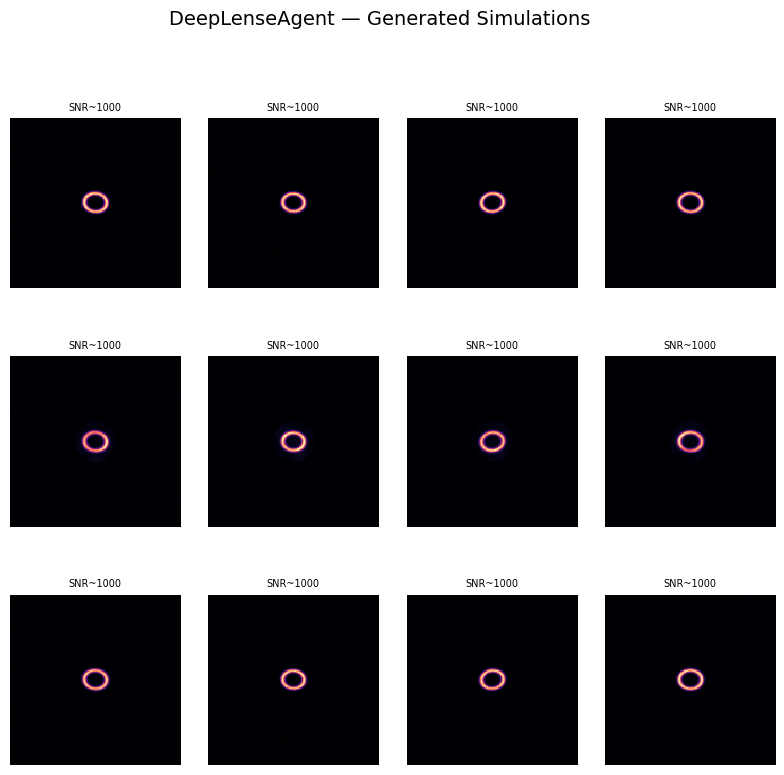

Visualization saved to ./deeplense_outputs/agent_simulation_grid.png


In [12]:
def visualize_results(results, labels=None):
    """Visualize a list of SimulationResult objects in a grid."""
    valid = [(r, l) for r, l in zip(results, labels or ['']*len(results))
             if r is not None and len(r.images) > 0]
    if not valid:
        print('No results to visualize.')
        return

    n_results = len(valid)
    n_cols    = min(4, max(r.request.num_images for r, _ in valid))
    fig = plt.figure(figsize=(n_cols * 2.5, n_results * 2.8))
    fig.suptitle('DeepLenseAgent — Generated Simulations', fontsize=14, y=1.01)
    gs  = gridspec.GridSpec(n_results, n_cols, figure=fig, hspace=0.4, wspace=0.1)

    for row, (result, label) in enumerate(valid):
        sub_type = result.request.substructure_type.value
        model    = result.request.model_config_name.value
        mode     = result.simulation_mode

        for col in range(n_cols):
            ax = fig.add_subplot(gs[row, col])
            if col < len(result.images):
                img  = result.images[col]
                meta = result.metadata[col]
                ax.imshow(img, cmap='magma', vmin=0, vmax=1, interpolation='nearest')
                ax.set_title(f'SNR~{meta.snr_estimate:.0f}', fontsize=7)
            else:
                ax.axis('off')
                continue
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(f'{model}\n{sub_type}\n({mode})',
                              fontsize=8, rotation=0, labelpad=90, va='center')

    plt.tight_layout()
    os.makedirs('./deeplense_outputs', exist_ok=True)
    plt.savefig('./deeplense_outputs/agent_simulation_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Visualization saved to ./deeplense_outputs/agent_simulation_grid.png')


visualize_results(
    [result_cdm, result_axion, result_nosub],
    ['CDM Subhalos (Model_I)', 'Axion Vortex (Model_II)', 'No Substructure']
)

## 9. Structured Output Validation

In [13]:
def print_result_summary(result: SimulationResult, label: str):
    if result is None:
        return
    print(f'\n── {label} ──────────────────────────────────────')
    print(f'  Summary        : {result.summary}')
    print(f'  Images         : {len(result.images)}')
    print(f'  Mode           : {result.simulation_mode}')
    print(f'  Time           : {result.total_time_sec:.2f}s')
    print(f'  Output files   : {len(result.output_paths)}')
    print(f'  Metadata valid : {all(isinstance(m, ImageMetadata) for m in result.metadata)}')
    if result.metadata:
        m0 = result.metadata[0]
        print(f'  Image[0] stats : peak={m0.peak_flux:.3f}, '
              f'mean={m0.mean_flux:.4f}, SNR~{m0.snr_estimate:.1f}')

    # Validate the SimulationRequest round-trips through Pydantic
    req_json   = result.request.model_dump_json()
    req_reload = SimulationRequest.model_validate_json(req_json)
    print(f'  Request JSON   : {len(req_json)} chars — round-trip valid: '
          f'{req_reload.num_images == result.request.num_images}')


for r, label in zip(
    [result_cdm, result_axion, result_nosub],
    ['CDM Subhalo (Model_I)', 'Axion Vortex (Model_II)', 'No Substructure']
):
    print_result_summary(r, label)


── CDM Subhalo (Model_I) ──────────────────────────────────────
  Summary        : Generated 8 cdm_subhalo lensing images using Model_I (z_lens=0.5, z_source=1.5). Mode: mock. Time: 0.06s. Saved to: ./deeplense_outputs
  Images         : 8
  Mode           : mock
  Time           : 0.06s
  Output files   : 8
  Metadata valid : True
  Image[0] stats : peak=1.000, mean=0.0111, SNR~1000.0
  Request JSON   : 602 chars — round-trip valid: True

── Axion Vortex (Model_II) ──────────────────────────────────────
  Summary        : Generated 6 axion_vortex lensing images using Model_II (z_lens=0.4, z_source=2.0). Mode: mock. Time: 0.04s. Saved to: ./deeplense_outputs
  Images         : 6
  Mode           : mock
  Time           : 0.04s
  Output files   : 6
  Metadata valid : True
  Image[0] stats : peak=1.000, mean=0.0117, SNR~1000.0
  Request JSON   : 626 chars — round-trip valid: True

── No Substructure ──────────────────────────────────────
  Summary        : Generated 4 no_substructure le

## 10. Discussion

### Agent Architecture Assessment

**Tool design:** Each tool has a single responsibility — validate, simulate, report. This means the agent can call them independently and retry individual steps on failure.

**Human-in-the-loop:** The clarification step is gated by ambiguity detection, not mandatory. Fully-specified prompts skip it entirely. This balances user experience with physics correctness.

**Pydantic validation as the first line of defense:** Physics constraints (z_source > z_lens, axion requires Model_II) are enforced at the model layer before any simulation code runs. Even if the LLM hallucinates an invalid parameter combination, Pydantic will catch it and return a structured error.

**Extensibility:** Adding Model_III or Model_IV requires only updating the `_simulate_full` backend — the agent, tools, and Pydantic models are unchanged.

### Bug fixes applied in this version

1. **`ImageMetadata.image_id: str`** — was typed as `int` but populated with `f"img_42_0"` strings everywhere, causing a type coercion failure.

2. **Single authoritative `tool_run_simulation`** — a previous draft cell redefined this function as a stub returning only `{'snr_estimate': ..., 'index': i}` — just 2 of the 13 required `ImageMetadata` fields, causing a `ValidationError` with 12 missing fields. The stub also omitted `output_paths`, `mode`, and `elapsed_sec` which `chat()` reads immediately after.

3. **Single authoritative `SimulationResult`** — a previous draft cell redefined this as `{success, message, num_images_generated, output_dir, parameters_used}`, stripping the `request`, `images`, `metadata`, `simulation_mode`, `total_time_sec`, and `summary` fields that `chat()` writes into it.

### Limitations

- Mock images are physically plausible but not lenstronomy ray-traced. Install lenstronomy + pyHalo for full simulation.
- The natural language parser is regex-based in demo mode. With a live Gemini API key, parsing is fully semantic.
- Multi-turn conversation state is held in-memory. A production system would persist this to a database.